# Fe_DOE: % Iron Concentrate 예측

**목표**: RSM/DOE 기반 피처 선별 → XGBoost → Silica 예측과 결합해 SI 역산

**데이터**:  (IQR 클리핑 + 3H lag 정렬 완료)

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from itertools import combinations

# 한글 폰트
_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]
_available  = {f.name for f in fm.fontManager.ttflist}
_font       = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

In [2]:
# ── Step 0. 데이터 로드 ────────────────────────────────────────────────────
df_raw = pd.read_csv("Silica_model_ready.csv", parse_dates=["date"], index_col="date")

X_COLS = [
    "% Iron Feed", "% Silica Feed",
    "Starch Flow", "Amina Flow", "Ore Pulp Flow", "Ore Pulp pH", "Ore Pulp Density",
    "Flotation Column 01 Air Flow", "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow", "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow", "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level", "Flotation Column 02 Level",
    "Flotation Column 03 Level", "Flotation Column 04 Level",
    "Flotation Column 05 Level", "Flotation Column 06 Level",
    "Flotation Column 07 Level",
]
X_LABELS  = [f"X{str(i+1).zfill(2)}" for i in range(len(X_COLS))]
PROTECTED = ["X01", "X02"]

TARGET = "% Iron Concentrate"   # 타겟: 원본값 사용 (log 변환 불필요)

df = df_raw[X_COLS + [TARGET]].copy()
print(f"데이터 shape: {df.shape}  ({df.index[0].date()} ~ {df.index[-1].date()})")
print(f"결측치: {df.isna().sum().sum()}개")
display(df[[TARGET]].describe().round(4))

데이터 shape: (4091, 22)  (2017-03-10 ~ 2017-09-09)
결측치: 0개


,% Iron Concentrate
count,4091.0000
mean,65.0476
std,1.1168
min,62.1350
25%,64.3600
50%,65.2100
75%,65.8600
max,68.0100


## Step 1. % Iron Concentrate 분포 확인

- 왜도 ≈ -0.52 → 거의 정규분포 → **log 변환 불필요**
- Silica(왜도 0.97)와 달리 이미 안정적인 분포

왜도 : -0.5199
첨도 : -0.1959
범위 : 62.1350 ~ 68.0100


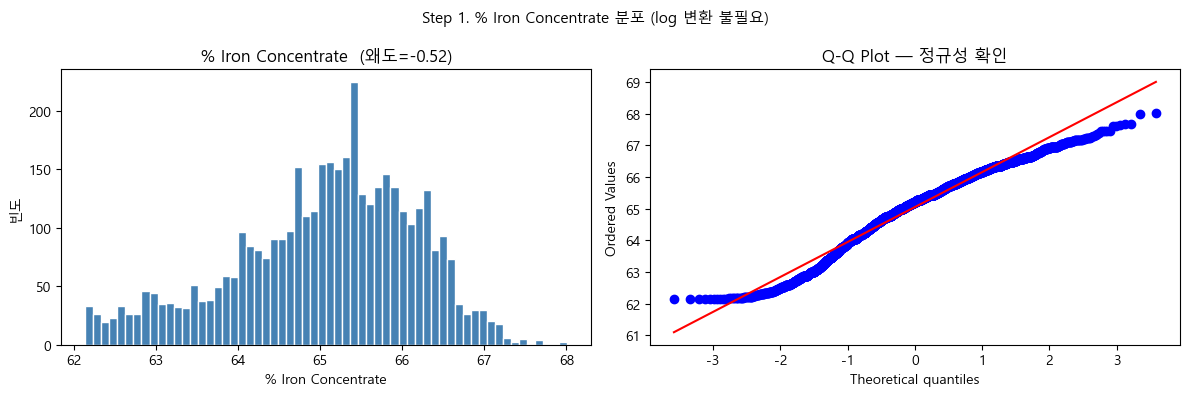

In [3]:
# ── Step 1. 분포 확인 ─────────────────────────────────────────────────────
print(f"왜도 : {df[TARGET].skew():.4f}")
print(f"첨도 : {df[TARGET].kurt():.4f}")
print(f"범위 : {df[TARGET].min():.4f} ~ {df[TARGET].max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET], bins=60, color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_title(f"% Iron Concentrate  (왜도={df[TARGET].skew():.2f})")
axes[0].set_xlabel("% Iron Concentrate"); axes[0].set_ylabel("빈도")

from scipy import stats
stats.probplot(df[TARGET], plot=axes[1])
axes[1].set_title("Q-Q Plot — 정규성 확인")

plt.suptitle("Step 1. % Iron Concentrate 분포 (log 변환 불필요)", fontsize=11)
plt.tight_layout(); plt.show()

## Step 2. OLS 회귀 — p-value 기반 유의 변수 선별

- X 표준화(StandardScaler) 후 OLS
- **p < 0.05** 기준
- X01(% Iron Feed), X02(% Silica Feed) 보호 변수

In [4]:
# ── Step 2. OLS ────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[X_COLS])
X_sm     = sm.add_constant(pd.DataFrame(X_scaled, columns=X_LABELS, index=df.index))

ols  = sm.OLS(df[TARGET], X_sm).fit()
result = pd.DataFrame({
    "Name"   : X_COLS,
    "coef"   : ols.params[X_LABELS].values,
    "p-value": ols.pvalues[X_LABELS].values,
}, index=X_LABELS)
result["유의(p<0.05)"] = result["p-value"] < 0.05

print(f"=== OLS 결과 | R² = {ols.rsquared:.4f} | 타겟: % Iron Concentrate ===")
display(result.sort_values("p-value").round(4))

sig_vars   = result[result["유의(p<0.05)"]].index.tolist()
insig_vars = result[~result["유의(p<0.05)"]].index.tolist()
print(f"유의 변수 ({len(sig_vars)}개): {sig_vars}")
print(f"비유의 변수 ({len(insig_vars)}개): {insig_vars}")

=== OLS 결과 | R² = 0.1297 | 타겟: % Iron Concentrate ===


,Name,coef,p-value,유의(p<0.05)
X06,Ore Pulp pH,0.2068,0.0000,True
X12,Flotation Column 05 Air Flow,0.1436,0.0000,True
X04,Amina Flow,-0.1370,0.0000,True
X11,Flotation Column 04 Air Flow,-0.1250,0.0000,True
X13,Flotation Column 06 Air Flow,-0.1815,0.0000,True
X05,Ore Pulp Flow,0.0783,0.0000,True
X19,Flotation Column 05 Level,0.1341,0.0001,True
X02,% Silica Feed,0.2464,0.0006,True
X09,Flotation Column 02 Air Flow,-0.1238,0.0008,True
X01,% Iron Feed,0.2200,0.0024,True


유의 변수 (14개): ['X01', 'X02', 'X04', 'X05', 'X06', 'X07', 'X08', 'X09', 'X10', 'X11', 'X12', 'X13', 'X14', 'X19']
비유의 변수 (7개): ['X03', 'X15', 'X16', 'X17', 'X18', 'X20', 'X21']


## Step 3. 주효과도 (Main Effects Plot)

- 각 변수를 5분위로 나눠 구간별 % Iron Concentrate 평균 시각화
- 노란 배경 = p < 0.05 유의 변수
- **Silica 주효과도와 방향 비교** (보통 반대 패턴)

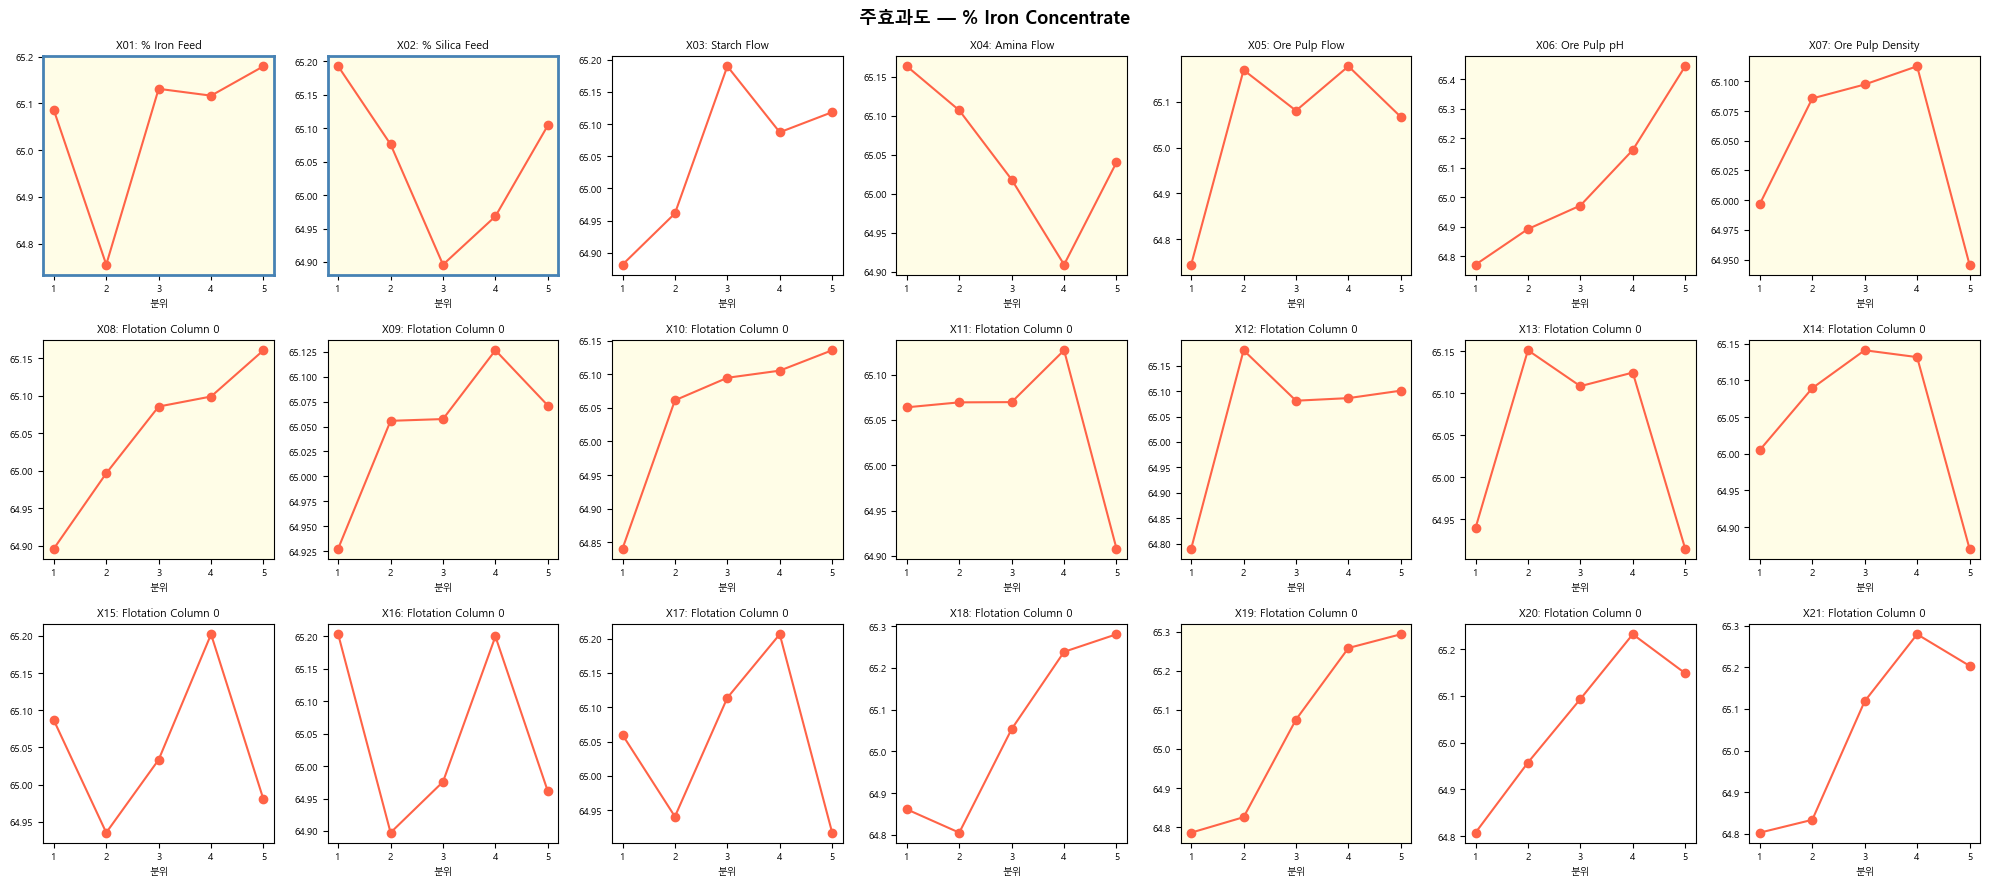

저장: main_effects_Fe.png


In [5]:
# ── Step 3. 주효과도 ────────────────────────────────────────────────────────
N_QUANTILE = 5
ncols = 7
nrows = (len(X_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
fig.suptitle("주효과도 — % Iron Concentrate", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(X_COLS, X_LABELS)):
    ax    = axes[i]
    q_bin = pd.qcut(df[col], N_QUANTILE, labels=False, duplicates="drop")
    means = df.groupby(q_bin)[TARGET].mean()
    if lbl in sig_vars:
        ax.set_facecolor("#fffde7")
    if lbl in PROTECTED:
        for spine in ax.spines.values():
            spine.set_edgecolor("steelblue"); spine.set_linewidth(2)
    ax.plot(means.index + 1, means.values, marker="o", color="tomato", lw=1.5)
    ax.set_title(f"{lbl}: {col[:18]}", fontsize=8)
    ax.set_xlabel("분위", fontsize=7); ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("main_effects_Fe.png", bbox_inches="tight")
plt.show()
print("저장: main_effects_Fe.png")

## Step 4. VIF — 다중공선성 확인

| VIF | 해석 |
|-----|------|
| 1~5 | 양호 |
| 5~10 | 주의 |
| >10 | 제거 고려 |

> X01, X02는 VIF가 높아도 제거하지 않습니다.

In [6]:
# ── Step 4. VIF ────────────────────────────────────────────────────────────
X_vif_df = pd.DataFrame(scaler.fit_transform(df[X_COLS]), columns=X_LABELS, index=df.index)
vif_df = pd.DataFrame({
    "Var" : X_LABELS,
    "Name": X_COLS,
    "VIF" : [variance_inflation_factor(X_vif_df.values, i) for i in range(len(X_LABELS))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df["보호"] = vif_df["Var"].isin(PROTECTED)
print("=== VIF 결과 ===")
display(vif_df.round(2))

=== VIF 결과 ===


,Var,Name,VIF,보호
0,X01,% Iron Feed,19.71,True
1,X02,% Silica Feed,19.33,True
2,X10,Flotation Column 03 Air Flow,16.34,False
3,X08,Flotation Column 01 Air Flow,14.03,False
4,X14,Flotation Column 07 Air Flow,7.58,False
5,X13,Flotation Column 06 Air Flow,7.18,False
6,X09,Flotation Column 02 Air Flow,5.11,False
7,X19,Flotation Column 05 Level,4.49,False
8,X21,Flotation Column 07 Level,4.35,False
9,X15,Flotation Column 01 Level,4.20,False


## Step 5. 4개 집계 변수 생성

14개 개별 Air/Level 컬럼 → 4개 집계 변수로 압축 (물리적 직렬구조 반영)

| 변수 | 정의 | 역할 |
|------|------|------|
| Rougher_Air | Air Col01~03 평균 | 앞단 거품 형성 |
| Cleaner_Air | Air Col04~07 평균 | 뒷단 Air 세기 |
| Rougher_Level | Level Col01~03 평균 | 앞단 거품층 높이 |
| Cleaner_Level | Level Col04~07 평균 | 뒷단 정밀 거품층 |

> Silica_DOE에서 이미 검증된 구조 재사용  
> 인과 쌍 (Rougher_Air × Rougher_Level, Cleaner_Air × Cleaner_Level) 은 RSM 교호작용에서 제외

집계 변수 생성 완료: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL']

=== 집계 변수 기초 통계 ===


,RA,CA,RL,CL
count,4091.000,4091.000,4091.000,4091.000
mean,279.471,295.559,524.700,424.072
std,28.102,13.972,115.743,67.729
min,177.644,247.725,328.851,299.846
25%,250.119,287.373,448.241,352.432
50%,299.748,299.886,499.851,404.573
75%,299.947,300.017,599.610,475.647
max,303.913,327.607,854.826,674.583


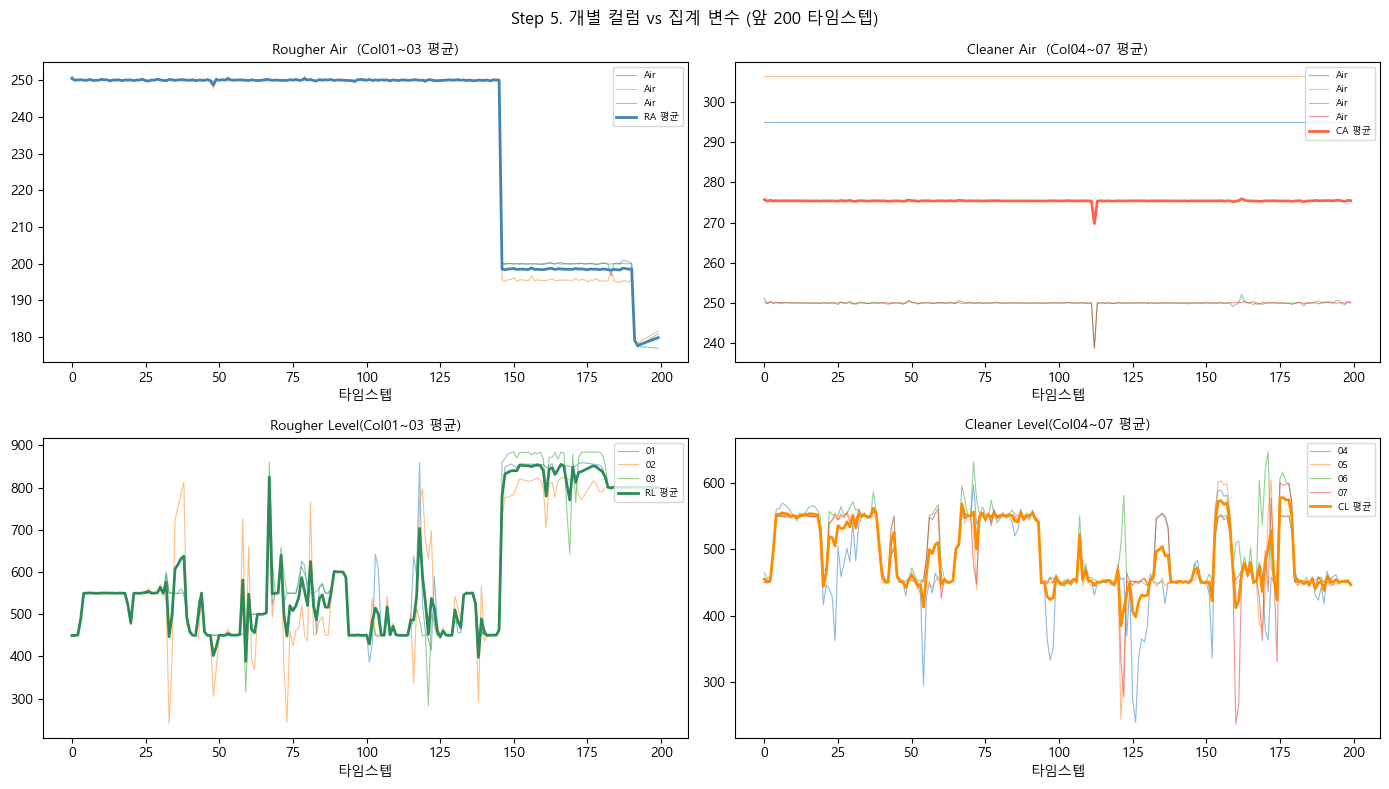

저장: agg_vars_Fe.png


In [7]:
# ── Step 5. 4개 집계 변수 생성 ──────────────────────────────────────────────
AIR_COLS   = [c for c in X_COLS if 'Air Flow' in c]
LEVEL_COLS = [c for c in X_COLS if 'Level' in c]

df_rsm = pd.DataFrame(index=df.index)

# 공정 투입 변수 (7개)
PROCESS_LABELS = ['P01','P02','P03','P04','P05','P06','P07']
for col, lbl in zip(X_COLS[:7], PROCESS_LABELS):
    df_rsm[lbl] = df[col]

# 집계 변수 (4개)
df_rsm['RA'] = df[AIR_COLS[:3]].mean(axis=1)   # Rougher Air   Col01~03
df_rsm['CA'] = df[AIR_COLS[3:]].mean(axis=1)   # Cleaner Air   Col04~07
df_rsm['RL'] = df[LEVEL_COLS[:3]].mean(axis=1) # Rougher Level Col01~03
df_rsm['CL'] = df[LEVEL_COLS[3:]].mean(axis=1) # Cleaner Level Col04~07

VAR_LABELS = list(df_rsm.columns)  # 11개

VAR_NAMES = {
    'P01': '% Iron Feed',      'P02': '% Silica Feed',
    'P03': 'Starch Flow',      'P04': 'Amina Flow',
    'P05': 'Ore Pulp Flow',    'P06': 'Ore Pulp pH',
    'P07': 'Ore Pulp Density',
    'RA' : 'Rougher Air (Col01~03)',
    'CA' : 'Cleaner Air (Col04~07)',
    'RL' : 'Rougher Level (Col01~03)',
    'CL' : 'Cleaner Level (Col04~07)',
}

# 인과 쌍: 같은 단계 내 Air->Level (RSM 교호작용에서 제외)
CAUSAL_PAIRS  = {('RA','RL'), ('CA','CL')}
PROTECTED_RSM = ['P01','P02']

print(f"집계 변수 생성 완료: {VAR_LABELS}")
print()
print("=== 집계 변수 기초 통계 ===")
display(df_rsm[['RA','CA','RL','CL']].describe().round(3))

# 시각화: 개별 vs 집계 비교 (앞 200 타임스텝)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    ('RA', AIR_COLS[:3],   'Rougher Air  (Col01~03 평균)', 'steelblue'),
    ('CA', AIR_COLS[3:],   'Cleaner Air  (Col04~07 평균)', 'tomato'),
    ('RL', LEVEL_COLS[:3], 'Rougher Level(Col01~03 평균)', 'seagreen'),
    ('CL', LEVEL_COLS[3:], 'Cleaner Level(Col04~07 평균)', 'darkorange'),
]
for ax, (agg, cols, title, color) in zip(axes.flatten(), pairs):
    for col in cols:
        ax.plot(df[col].values[:200], lw=0.8, alpha=0.5, label=col.split()[-2])
    ax.plot(df_rsm[agg].values[:200], lw=2, color=color, label=f'{agg} 평균')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlabel('타임스텝')

plt.suptitle("Step 5. 개별 컬럼 vs 집계 변수 (앞 200 타임스텝)", fontsize=12)
plt.tight_layout()
plt.savefig("agg_vars_Fe.png", bbox_inches="tight")
plt.show()
print("저장: agg_vars_Fe.png")

## Step 6. RSM + Backward Elimination

- 11개 변수 → 주효과(11) + 2차항(11) + 교호작용(54) = **77항**
- 인과 쌍 제외: `RA×RL`, `CA×CL` (같은 단계 내 Air→Level 인과)
- p > 0.05 항을 하나씩 제거 → 모든 항 p < 0.05 될 때까지
- 타겟: **% Iron Concentrate 원본값** (log 변환 없음)

In [8]:
# ── Step 6-1. RSM 항 생성 ────────────────────────────────────────────────────
scaler_rsm   = StandardScaler()
X_rsm_scaled = scaler_rsm.fit_transform(df_rsm)
X_rsm_df     = pd.DataFrame(X_rsm_scaled, columns=VAR_LABELS, index=df.index)

rsm_terms = {}

# 주효과
for lbl in VAR_LABELS:
    rsm_terms[lbl] = X_rsm_df[lbl]

# 2차항
for lbl in VAR_LABELS:
    rsm_terms[f'{lbl}^2'] = X_rsm_df[lbl] ** 2

# 교호작용 (인과 쌍 제외)
for a, b in combinations(VAR_LABELS, 2):
    if (a, b) not in CAUSAL_PAIRS and (b, a) not in CAUSAL_PAIRS:
        rsm_terms[f'{a}x{b}'] = X_rsm_df[a] * X_rsm_df[b]

X_rsm_full = sm.add_constant(pd.DataFrame(rsm_terms, index=df.index))
print(f"RSM 총 항 수: {X_rsm_full.shape[1]-1}개 (절편 제외)")
print(f"  주효과: {len(VAR_LABELS)}개")
print(f"  2차항 : {len(VAR_LABELS)}개")
print(f"  교호작용: {X_rsm_full.shape[1]-1 - 2*len(VAR_LABELS)}개")

RSM 총 항 수: 75개 (절편 제외)
  주효과: 11개
  2차항 : 11개
  교호작용: 53개


In [9]:
# ── Step 6-2. Backward Elimination ──────────────────────────────────────────
PROTECTED_TERMS = set(PROTECTED_RSM)  # P01, P02 주효과 보호

def term_to_name(term):
    """항 코드 → 한글 이름 변환"""
    if '^2' in term:
        lbl = term[:-2]
        return f'{VAR_NAMES.get(lbl, lbl)}²'
    elif 'x' in term:
        a, b = term.split('x', 1)
        return f'{VAR_NAMES.get(a,a)} × {VAR_NAMES.get(b,b)}'
    return VAR_NAMES.get(term, term)

remaining_terms = list(rsm_terms.keys())
step_log = []

print("── Backward Elimination 시작 ────────────────────────────────────────────")
iteration = 0
while True:
    iteration += 1
    X_curr = sm.add_constant(pd.DataFrame({t: rsm_terms[t] for t in remaining_terms}, index=df.index))
    model  = sm.OLS(df[TARGET], X_curr).fit()

    pvals = model.pvalues.drop('const')
    # 보호 변수 제외하고 최대 p-value 찾기
    candidates = pvals[~pvals.index.isin(PROTECTED_TERMS)]
    max_p = candidates.max()

    if max_p <= 0.05:
        print(f"  ✓ 모든 항 p < 0.05 — 종료 (반복 {iteration}회, 잔여 {len(remaining_terms)}개)")
        break

    drop_term = candidates.idxmax()
    step_log.append({'제거 항': term_to_name(drop_term), 'p-value': round(max_p, 4)})
    remaining_terms.remove(drop_term)

    if iteration % 10 == 0:
        print(f"  [{iteration:3d}회] 제거: {term_to_name(drop_term):<45s}  p={max_p:.4f}  잔여={len(remaining_terms)}개")

print(f"총 {len(rsm_terms) - len(remaining_terms)}개 제거 → {len(remaining_terms)}개 잔류")

── Backward Elimination 시작 ────────────────────────────────────────────
  [ 10회] 제거: Amina Flow × Ore Pulp Density                  p=0.6988  잔여=65개
  [ 20회] 제거: Starch Flow                                    p=0.3715  잔여=55개
  [ 30회] 제거: Ore Pulp pH × Cleaner Level (Col04~07)         p=0.1323  잔여=45개
  ✓ 모든 항 p < 0.05 — 종료 (반복 39회, 잔여 37개)
총 38개 제거 → 37개 잔류


In [10]:
# ── Step 6-3. 최종 RSM 결과 ─────────────────────────────────────────────────
X_final = sm.add_constant(pd.DataFrame({t: rsm_terms[t] for t in remaining_terms}, index=df.index))
final_model = sm.OLS(df[TARGET], X_final).fit()

result_df = pd.DataFrame({
    '항'     : [term_to_name(t) for t in remaining_terms],
    'coef'   : final_model.params[remaining_terms].values,
    'p-value': final_model.pvalues[remaining_terms].values,
}, index=remaining_terms).sort_values('p-value')

print(f"=== 최종 RSM 결과 | R² = {final_model.rsquared:.4f} | 타겟: % Iron Concentrate ===")
display(result_df.round(4))

# 항 유형별 분류
main_sig   = [t for t in remaining_terms if '^' not in t and 'x' not in t]
quad_sig   = [t for t in remaining_terms if '^2' in t]
inter_sig  = [t for t in remaining_terms if 'x' in t]

print(f"유의 주효과  ({len(main_sig)}개): {main_sig}")
print(f"유의 2차항   ({len(quad_sig)}개): {quad_sig}")
print(f"유의 교호작용({len(inter_sig)}개): {inter_sig}")

# XGBoost 실험 B에 쓸 집계 변수 목록 추출
rsm_main_vars = list(dict.fromkeys(
    [t for t in main_sig if t in VAR_LABELS] +
    [t.replace('^2','') for t in quad_sig] +
    [s for t in inter_sig for s in t.split('x',1)]
))
rsm_main_vars = [v for v in VAR_LABELS if v in rsm_main_vars]
print(f"XGBoost 실험 B 후보 변수 ({len(rsm_main_vars)}개): {rsm_main_vars}")

=== 최종 RSM 결과 | R² = 0.1803 | 타겟: % Iron Concentrate ===


,항,coef,p-value
P06,Ore Pulp pH,0.2166,0.0000
CL,Cleaner Level (Col04~07),0.1987,0.0000
CL^2,Cleaner Level (Col04~07)²,-0.1677,0.0000
P01xRL,% Iron Feed × Rougher Level (Col01~03),0.6572,0.0000
P02xRL,% Silica Feed × Rougher Level (Col01~03),0.6162,0.0000
P03xCA,Starch Flow × Cleaner Air (Col04~07),-0.1301,0.0000
P01,% Iron Feed,0.5254,0.0000
P05^2,Ore Pulp Flow²,-0.0658,0.0000
P02,% Silica Feed,0.4906,0.0000
RA^2,Rougher Air (Col01~03)²,-0.0764,0.0000


유의 주효과  (5개): ['P01', 'P02', 'P04', 'P06', 'CL']
유의 2차항   (6개): ['P01^2', 'P05^2', 'P06^2', 'RA^2', 'RL^2', 'CL^2']
유의 교호작용(26개): ['P01xP02', 'P01xP06', 'P01xP07', 'P01xRA', 'P01xCA', 'P01xRL', 'P01xCL', 'P02xP04', 'P02xP06', 'P02xP07', 'P02xRA', 'P02xCA', 'P02xRL', 'P02xCL', 'P03xP07', 'P03xCA', 'P03xCL', 'P04xP06', 'P04xRA', 'P05xP06', 'P05xCA', 'P05xCL', 'P06xCA', 'P06xRL', 'P07xRL', 'RAxCL']
XGBoost 실험 B 후보 변수 (11개): ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL']


## Step 7. VIF — 최종 피처 다중공선성 확인

RSM 선별 후 집계 변수(11개) 간 VIF 검토  
- VIF > 10 → 제거 고려 (P01, P02 보호)
- 집계 변수(RA/CA/RL/CL)는 개별 컬럼보다 VIF가 낮아야 정상

In [11]:
# ── Step 7. VIF ─────────────────────────────────────────────────────────────
def calc_vif(df_in):
    X_c  = sm.add_constant(df_in)
    cols = df_in.columns.tolist()
    vifs = [variance_inflation_factor(X_c.values, i+1) for i in range(len(cols))]
    return pd.DataFrame({
        '변수'  : cols,
        '피처명': [VAR_NAMES.get(c, c) for c in cols],
        'VIF'   : vifs,
        '보호'  : [c in PROTECTED_RSM for c in cols],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

print("── 1차 VIF (RSM 선별 11개) ──────────────────────────────────────────────")
display(calc_vif(df_rsm[rsm_main_vars]).round(2))

# 순차 제거 (비보호 VIF > 10)
remaining_b = list(rsm_main_vars)
removed_vif = []

print("── 순차 제거 (비보호 VIF > 10) ─────────────────────────────────────────")
while True:
    vif_df     = calc_vif(df_rsm[remaining_b])
    candidates = vif_df[(vif_df['VIF'] > 10) & (~vif_df['변수'].isin(PROTECTED_RSM))]
    if candidates.empty:
        print("  ✓ 비보호 변수 중 VIF > 10 없음 — 종료")
        break
    tgt = candidates.iloc[0]['변수']
    print(f"  제거: {VAR_NAMES.get(tgt,tgt):<35s}  VIF = {candidates.iloc[0]['VIF']:.2f}")
    remaining_b.remove(tgt)
    removed_vif.append(tgt)

print(f"── 최종 VIF ({len(remaining_b)}개) ─────────────────────────────────────────────")
display(calc_vif(df_rsm[remaining_b]).round(2))

print(f"=== 최종 확정 변수 ({len(remaining_b)}개) ===")
for v in remaining_b:
    print(f"  {v}: {VAR_NAMES.get(v,v)}")
if removed_vif:
    print(f"VIF 제거 변수 ({len(removed_vif)}개): {removed_vif}")

── 1차 VIF (RSM 선별 11개) ──────────────────────────────────────────────


,변수,피처명,VIF,보호
0,P01,% Iron Feed,18.97,True
1,P02,% Silica Feed,18.76,True
2,RA,Rougher Air (Col01~03),2.37,False
3,CA,Cleaner Air (Col04~07),2.34,False
4,P04,Amina Flow,2.22,False
5,P07,Ore Pulp Density,2.02,False
6,RL,Rougher Level (Col01~03),1.94,False
7,P03,Starch Flow,1.59,False
8,CL,Cleaner Level (Col04~07),1.46,False
9,P05,Ore Pulp Flow,1.27,False


── 순차 제거 (비보호 VIF > 10) ─────────────────────────────────────────
  ✓ 비보호 변수 중 VIF > 10 없음 — 종료
── 최종 VIF (11개) ─────────────────────────────────────────────


,변수,피처명,VIF,보호
0,P01,% Iron Feed,18.97,True
1,P02,% Silica Feed,18.76,True
2,RA,Rougher Air (Col01~03),2.37,False
3,CA,Cleaner Air (Col04~07),2.34,False
4,P04,Amina Flow,2.22,False
5,P07,Ore Pulp Density,2.02,False
6,RL,Rougher Level (Col01~03),1.94,False
7,P03,Starch Flow,1.59,False
8,CL,Cleaner Level (Col04~07),1.46,False
9,P05,Ore Pulp Flow,1.27,False


=== 최종 확정 변수 (11개) ===
  P01: % Iron Feed
  P02: % Silica Feed
  P03: Starch Flow
  P04: Amina Flow
  P05: Ore Pulp Flow
  P06: Ore Pulp pH
  P07: Ore Pulp Density
  RA: Rougher Air (Col01~03)
  CA: Cleaner Air (Col04~07)
  RL: Rougher Level (Col01~03)
  CL: Cleaner Level (Col04~07)


## Step 8. XGBoost 비교 실험 — 실험 A vs 실험 B

| | 실험 A | 실험 B |
|--|--------|--------|
| 피처 | 21개 개별 변수 + lag 2개 | 11개 집계 변수 + lag 2개 |
| lag | Fe_lag1 (1H 전), Fe_lag2 (2H 전) | 동일 |
| 타겟 | % Iron Concentrate (원본, log 없음) | 동일 |

- Train 70% / Test 30% (시계열 순서 유지)
- 10-fold Cross-validation

In [12]:
# ── Step 8-1. lag 피처 + Train/Test 분할 ────────────────────────────────────
# Fe lag 피처 (% Iron Concentrate 이전값)
df['Fe_lag1'] = df[TARGET].shift(1)   # 1H 전
df['Fe_lag2'] = df[TARGET].shift(2)   # 2H 전
df_rsm['Fe_lag1'] = df['Fe_lag1']
df_rsm['Fe_lag2'] = df['Fe_lag2']

LAG_COLS = ['Fe_lag1', 'Fe_lag2']

# lag NaN 제거 후 분할
valid_idx       = df.dropna(subset=LAG_COLS).index
df_v            = df.loc[valid_idx]
df_rsm_v        = df_rsm.loc[valid_idx]

split           = int(len(df_v) * 0.7)
y               = df_v[TARGET]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 실험 A: 21개 개별 변수 + lag
X_A       = df_v[X_COLS + LAG_COLS]
X_A_train = X_A.iloc[:split]
X_A_test  = X_A.iloc[split:]

# 실험 B: 11개 집계 변수 + lag
X_B       = df_rsm_v[remaining_b + LAG_COLS]
X_B_train = X_B.iloc[:split]
X_B_test  = X_B.iloc[split:]

print(f"Train: {len(y_train):,}행 | Test: {len(y_test):,}행")
print(f"실험 A 피처: {len(X_A.columns)}개  {list(X_A.columns)}")
print(f"실험 B 피처: {len(X_B.columns)}개  {list(X_B.columns)}")

# 분포 확인
print(f"훈련셋 Fe 평균: {y_train.mean():.4f} | 표준편차: {y_train.std():.4f}")
print(f"테스트셋 Fe 평균: {y_test.mean():.4f} | 표준편차: {y_test.std():.4f}")

Train: 2,862행 | Test: 1,227행
실험 A 피처: 23개  ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', 'Fe_lag1', 'Fe_lag2']
실험 B 피처: 13개  ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL', 'Fe_lag1', 'Fe_lag2']
훈련셋 Fe 평균: 65.1294 | 표준편차: 1.1207
테스트셋 Fe 평균: 64.8543 | 표준편차: 1.0829


In [13]:
# ── Step 8-2. XGBoost 학습 함수 ─────────────────────────────────────────────
XGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
K = 10

def run_xgb(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []
    for k in range(K):
        v0 = k * fold_size
        v1 = (k+1)*fold_size if k < K-1 else len(X_tr)
        vi = list(range(v0, v1))
        ti = list(range(0, v0)) + list(range(v1, len(X_tr)))
        m  = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
        m.fit(X_tr.iloc[ti], y_train.iloc[ti])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[vi], m.predict(X_tr.iloc[vi]))))
    model     = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    print(f"[{label}]")
    print(f"  CV   RMSE: {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test R²  : {test_r2:.4f}")
    return {'model': model, 'pred': pred, 'cv_rmse': np.mean(cv_rmses),
            'test_rmse': test_rmse, 'test_r2': test_r2}

print("XGBoost 학습 시작...")
res_A = run_xgb(X_A_train, X_A_test, f"실험 A — 개별 {len(X_A.columns)}개")
res_B = run_xgb(X_B_train, X_B_test, f"실험 B — 집계 {len(X_B.columns)}개")
model_A, model_B = res_A['model'], res_B['model']

XGBoost 학습 시작...
[실험 A — 개별 23개]
  CV   RMSE: 0.7684 ± 0.0819
  Test RMSE: 0.8533
  Test R²  : 0.3786
[실험 B — 집계 13개]
  CV   RMSE: 0.7748 ± 0.0807
  Test RMSE: 0.8505
  Test R²  : 0.3827


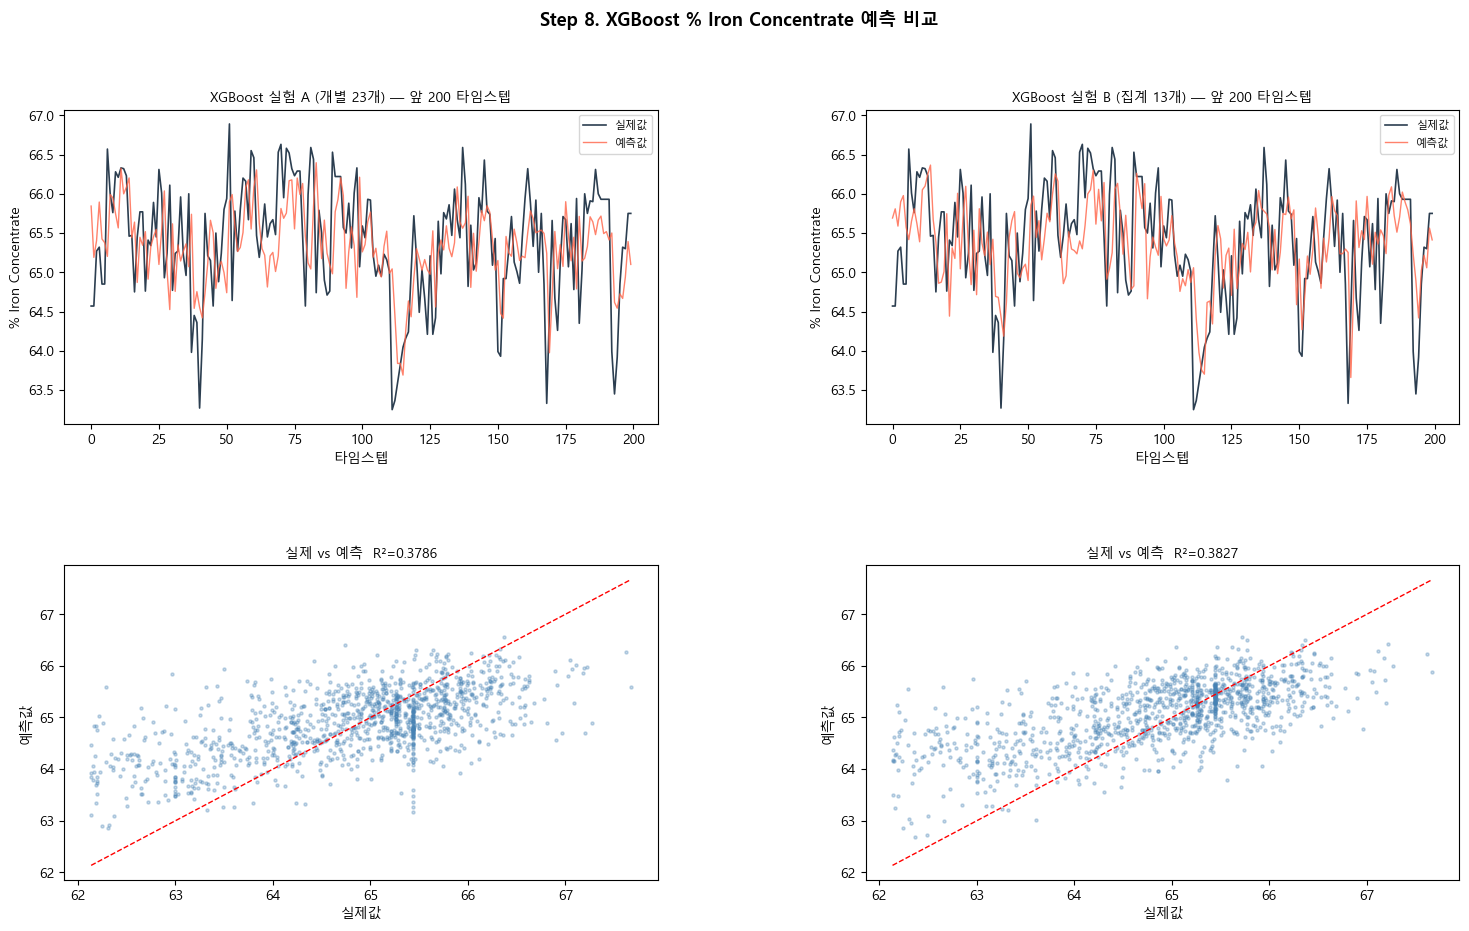

  모델                              Test RMSE   Test R²
-------------------------------------------------------
  실험 A (개별 23개)                      0.8533    0.3786
  실험 B (집계 13개)                      0.8505    0.3827


In [14]:
# ── Step 8-3. 결과 시각화 + 비교표 ─────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

for idx, (res, label) in enumerate([(res_A, f'실험 A (개별 {len(X_A.columns)}개)'),
                                     (res_B, f'실험 B (집계 {len(X_B.columns)}개)')]):
    pred  = res['pred']
    y_arr = y_test.values

    ax1 = fig.add_subplot(gs[0, idx])
    ax1.plot(y_arr[:200],  color='#2c3e50', lw=1.2, label='실제값')
    ax1.plot(pred[:200],   color='tomato',  lw=1.0, alpha=0.8, label='예측값')
    ax1.set_title(f'XGBoost {label} — 앞 200 타임스텝', fontsize=10)
    ax1.set_xlabel('타임스텝'); ax1.set_ylabel('% Iron Concentrate')
    ax1.legend(fontsize=8)

    ax2 = fig.add_subplot(gs[1, idx])
    ax2.scatter(y_arr, pred, alpha=0.3, s=5, color='steelblue')
    mn, mx = min(y_arr.min(), pred.min()), max(y_arr.max(), pred.max())
    ax2.plot([mn, mx], [mn, mx], 'r--', lw=1)
    ax2.set_title(f'실제 vs 예측  R²={res["test_r2"]:.4f}', fontsize=10)
    ax2.set_xlabel('실제값'); ax2.set_ylabel('예측값')

plt.suptitle('Step 8. XGBoost % Iron Concentrate 예측 비교', fontsize=13, fontweight='bold')
plt.savefig('xgb_Fe_comparison.png', bbox_inches='tight')
plt.show()

# 비교표
print("=" * 55)
print(f"  {'모델':<30s}  {'Test RMSE':>9}  {'Test R²':>8}")
print("-" * 55)
print(f"  {'실험 A (개별 '+str(len(X_A.columns))+'개)':<30s}  {res_A['test_rmse']:>9.4f}  {res_A['test_r2']:>8.4f}")
print(f"  {'실험 B (집계 '+str(len(X_B.columns))+'개)':<30s}  {res_B['test_rmse']:>9.4f}  {res_B['test_r2']:>8.4f}")
print("=" * 55)

## Step 9. Partial Dependence Plot (PDP)

주효과도와의 차이:
- **주효과도**: 분위별 단순 평균 → 다른 변수 영향 섞임
- **PDP**: 해당 변수만 바꾸고 나머지는 고정 → 순수 개별 효과

**RA, CA, RL, CL** 4개 비교 → Rougher vs Cleaner 물리 구조 검증

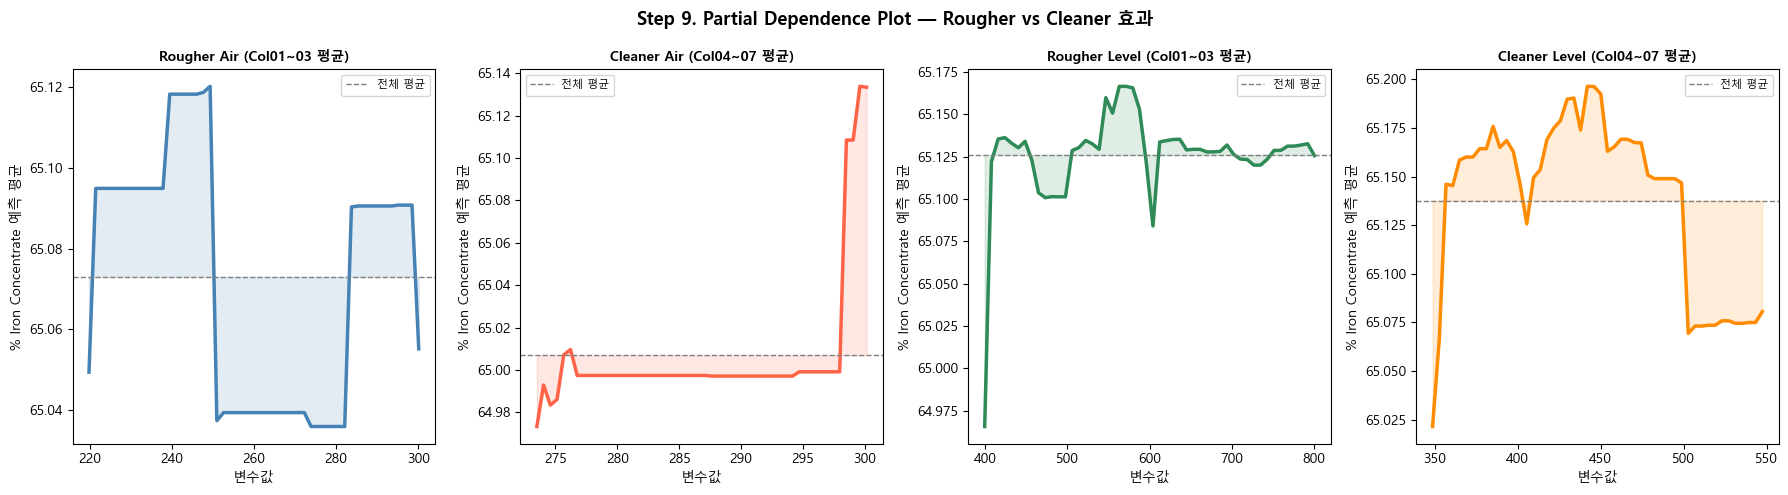

저장: pdp_Fe.png


In [15]:
# ── Step 9. Partial Dependence Plot ─────────────────────────────────────────
# 수동 PDP 구현 (sklearn 버전 호환 문제 방지)
def compute_pdp(model, X_data, feature, n_grid=50):
    grid  = np.linspace(X_data[feature].quantile(0.05),
                        X_data[feature].quantile(0.95), n_grid)
    means = []
    for val in grid:
        X_tmp          = X_data.copy()
        X_tmp[feature] = val
        means.append(model.predict(X_tmp).mean())
    return grid, np.array(means)

# PDP 대상: 4개 집계 변수 (실험 B 모델 사용)
AGG_VARS  = ['RA', 'CA', 'RL', 'CL']
AGG_NAMES = {
    'RA': 'Rougher Air (Col01~03 평균)',
    'CA': 'Cleaner Air (Col04~07 평균)',
    'RL': 'Rougher Level (Col01~03 평균)',
    'CL': 'Cleaner Level (Col04~07 평균)',
}
COLORS = {'RA':'steelblue', 'CA':'tomato', 'RL':'seagreen', 'CL':'darkorange'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

pdp_results = {}
for ax, var in zip(axes, AGG_VARS):
    grid, means = compute_pdp(model_B, X_B_train, var)
    pdp_results[var] = (grid, means)

    ax.plot(grid, means, lw=2.5, color=COLORS[var])
    ax.fill_between(grid, means, means.mean(), alpha=0.15, color=COLORS[var])
    ax.axhline(means.mean(), color='gray', lw=1, ls='--', label='전체 평균')
    ax.set_title(AGG_NAMES[var], fontsize=10, fontweight='bold')
    ax.set_xlabel('변수값')
    ax.set_ylabel('% Iron Concentrate 예측 평균')
    ax.legend(fontsize=8)

plt.suptitle('Step 9. Partial Dependence Plot — Rougher vs Cleaner 효과',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp_Fe.png', bbox_inches='tight')
plt.show()
print("저장: pdp_Fe.png")


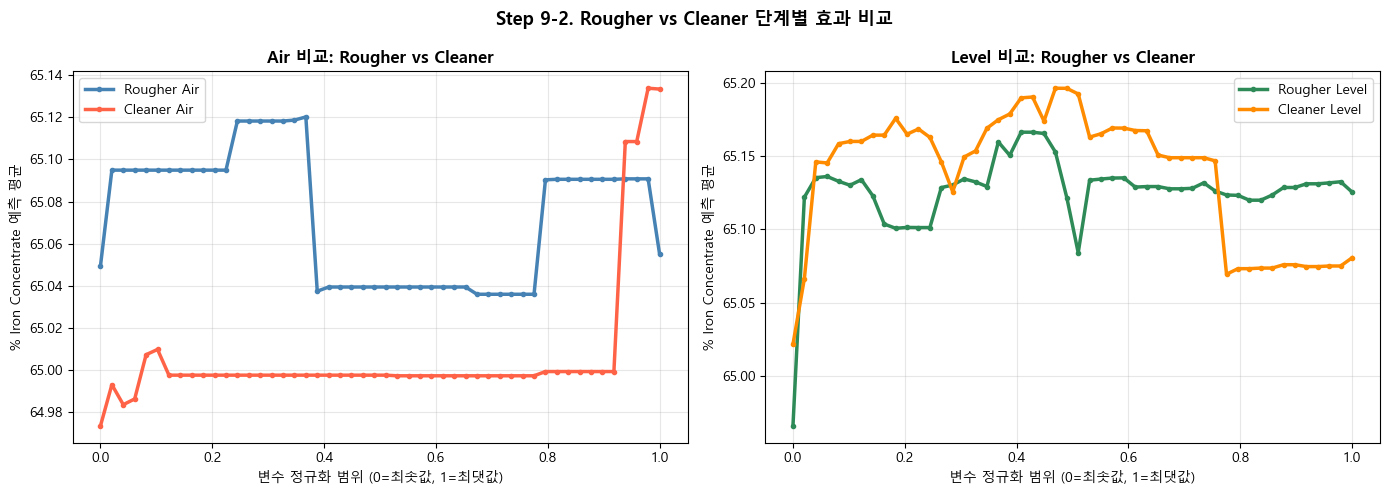

=== PDP 효과 크기 요약 (최대-최소) ===
  RA (Rougher Air (Col01~03)        ): 0.0843 %p
  CA (Cleaner Air (Col04~07)        ): 0.1605 %p
  RL (Rougher Level (Col01~03)      ): 0.2007 %p
  CL (Cleaner Level (Col04~07)      ): 0.1750 %p


In [16]:
# ── Step 9-2. Rougher vs Cleaner 비교 시각화 ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Air 비교: Rougher vs Cleaner
ax = axes[0]
for var, label in [('RA','Rougher Air'), ('CA','Cleaner Air')]:
    grid, means = pdp_results[var]
    # x축을 0~1로 정규화해서 같은 축에 비교
    x_norm = (grid - grid.min()) / (grid.max() - grid.min())
    ax.plot(x_norm, means, lw=2.5, color=COLORS[var], label=label, marker='o', ms=3)
ax.set_title('Air 비교: Rougher vs Cleaner', fontsize=12, fontweight='bold')
ax.set_xlabel('변수 정규화 범위 (0=최솟값, 1=최댓값)')
ax.set_ylabel('% Iron Concentrate 예측 평균')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Level 비교: Rougher vs Cleaner
ax = axes[1]
for var, label in [('RL','Rougher Level'), ('CL','Cleaner Level')]:
    grid, means = pdp_results[var]
    x_norm = (grid - grid.min()) / (grid.max() - grid.min())
    ax.plot(x_norm, means, lw=2.5, color=COLORS[var], label=label, marker='o', ms=3)
ax.set_title('Level 비교: Rougher vs Cleaner', fontsize=12, fontweight='bold')
ax.set_xlabel('변수 정규화 범위 (0=최솟값, 1=최댓값)')
ax.set_ylabel('% Iron Concentrate 예측 평균')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('Step 9-2. Rougher vs Cleaner 단계별 효과 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp_Fe_comparison.png', bbox_inches='tight')
plt.show()

# 효과 크기 요약
print("=== PDP 효과 크기 요약 (최대-최소) ===")
for var in AGG_VARS:
    grid, means = pdp_results[var]
    effect = means.max() - means.min()
    print(f"  {var} ({VAR_NAMES[var]:<30s}): {effect:.4f} %p")

## Step 8-추가. lag 제거 실험 — 공정 변수만으로 예측 가능한가?

lag 피처의 기여도 측정:
- **with lag**: 공정 변수 + Fe_lag1, Fe_lag2
- **without lag**: 공정 변수만

→ R² 차이 = lag가 설명하는 분산 비율

In [17]:
# ── lag 제거 실험 ────────────────────────────────────────────────────────────
# lag 없는 피처셋 (공정 변수만)
X_A_nolag       = df_v[X_COLS]
X_A_nolag_train = X_A_nolag.iloc[:split]
X_A_nolag_test  = X_A_nolag.iloc[split:]

X_B_nolag       = df_rsm_v[remaining_b]
X_B_nolag_train = X_B_nolag.iloc[:split]
X_B_nolag_test  = X_B_nolag.iloc[split:]

print("XGBoost 학습 (lag 없음)...")
res_A_nl = run_xgb(X_A_nolag_train, X_A_nolag_test, f"실험 A — 개별 {len(X_COLS)}개 (lag 없음)")
res_B_nl = run_xgb(X_B_nolag_train, X_B_nolag_test, f"실험 B — 집계 {len(remaining_b)}개 (lag 없음)")

# ── 4개 실험 종합 비교표 ─────────────────────────────────────────────────────
print()
print("=" * 65)
print(f"  {'모델':<35s}  {'RMSE':>8}  {'R²':>8}  {'피처':>5}")
print("-" * 65)
rows = [
    (f"A — 개별 {len(X_A.columns)}개 (with lag)",    res_A,    len(X_A.columns)),
    (f"B — 집계 {len(X_B.columns)}개 (with lag)",    res_B,    len(X_B.columns)),
    (f"A — 개별 {len(X_COLS)}개  (no lag)",          res_A_nl, len(X_COLS)),
    (f"B — 집계 {len(remaining_b)}개  (no lag)",     res_B_nl, len(remaining_b)),
]
for label, res, n in rows:
    print(f"  {label:<35s}  {res['test_rmse']:>8.4f}  {res['test_r2']:>8.4f}  {n:>5}")
print("=" * 65)

# lag 기여도
lag_contrib_A = res_A['test_r2'] - res_A_nl['test_r2']
lag_contrib_B = res_B['test_r2'] - res_B_nl['test_r2']
print(f"lag 기여 R² (A): {lag_contrib_A:+.4f}")
print(f"lag 기여 R² (B): {lag_contrib_B:+.4f}")
print(f"→ lag가 R²를 {'높임' if lag_contrib_B > 0 else '낮춤'} ({lag_contrib_B:+.4f}p)")

XGBoost 학습 (lag 없음)...
[실험 A — 개별 21개 (lag 없음)]
  CV   RMSE: 1.1620 ± 0.1703
  Test RMSE: 1.2241
  Test R²  : -0.2790
[실험 B — 집계 11개 (lag 없음)]
  CV   RMSE: 1.1746 ± 0.1627
  Test RMSE: 1.1561
  Test R²  : -0.1408

  모델                                       RMSE        R²     피처
-----------------------------------------------------------------
  A — 개별 23개 (with lag)                  0.8533    0.3786     23
  B — 집계 13개 (with lag)                  0.8505    0.3827     13
  A — 개별 21개  (no lag)                   1.2241   -0.2790     21
  B — 집계 11개  (no lag)                   1.1561   -0.1408     11
lag 기여 R² (A): +0.6576
lag 기여 R² (B): +0.5235
→ lag가 R²를 높임 (+0.5235p)


## 최종 종합 비교 — lag 포함 vs 미포함

  모델                                     CV RMSE  Test RMSE   Test R²
--------------------------------------------------------------------
  A — 개별 21개 + lag 2개                     0.7684     0.8533    0.3786
  B — 집계 11개 + lag 2개                     0.7748     0.8505    0.3827
  A — 개별 21개  (no lag)                    1.1620     1.2241   -0.2790
  B — 집계 11개  (no lag)                    1.1746     1.1561   -0.1408
=== 기여도 분석 ===
  lag 기여 R²  (A 기준): +0.6576
  lag 기여 R²  (B 기준): +0.5235
  집계 변수 기여 (with lag): +0.0041
  집계 변수 기여 (no  lag): +0.1382
최고 성능: B — 집계 11개 + lag 2개  →  Test RMSE 0.8505 / R² 0.3827


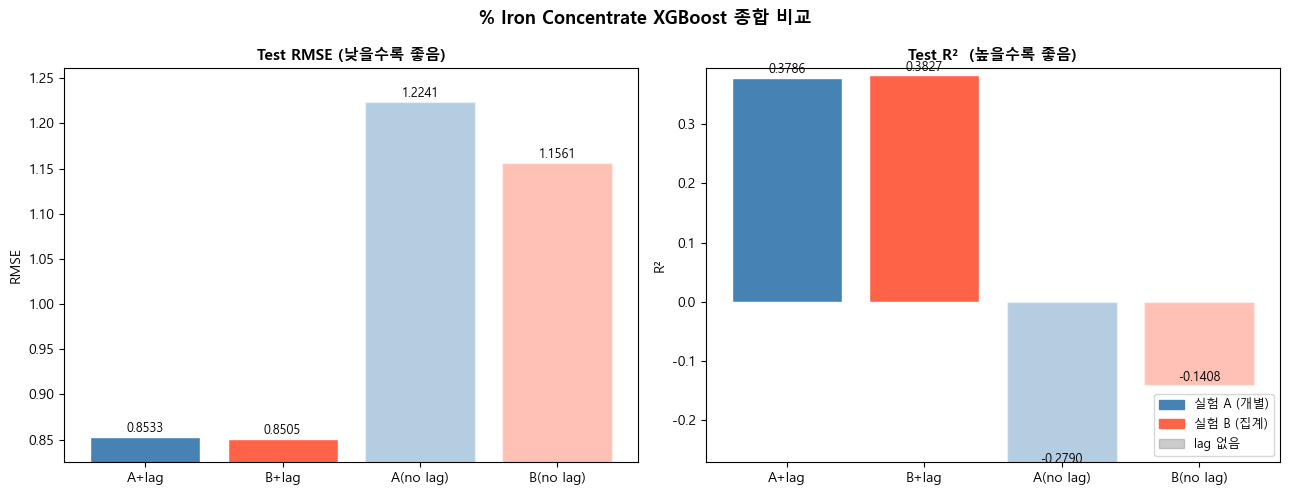

저장: xgb_Fe_final_summary.png


In [18]:
# ── 최종 종합 비교표 ─────────────────────────────────────────────────────────
all_results = [
    ("A — 개별 21개 + lag 2개",  res_A,    len(X_A.columns)),
    ("B — 집계 11개 + lag 2개",  res_B,    len(X_B.columns)),
    ("A — 개별 21개  (no lag)",  res_A_nl, len(X_COLS)),
    ("B — 집계 11개  (no lag)",  res_B_nl, len(remaining_b)),
]

print("=" * 68)
print(f"  {'모델':<36s}  {'CV RMSE':>8}  {'Test RMSE':>9}  {'Test R²':>8}")
print("-" * 68)
for label, res, n in all_results:
    print(f"  {label:<36s}  {res['cv_rmse']:>8.4f}  {res['test_rmse']:>9.4f}  {res['test_r2']:>8.4f}")
print("=" * 68)

best     = min(all_results, key=lambda x: x[1]['test_rmse'])
lag_A    = res_A['test_r2']    - res_A_nl['test_r2']
lag_B    = res_B['test_r2']    - res_B_nl['test_r2']
agg_lag  = res_B['test_r2']    - res_A['test_r2']
agg_nolag= res_B_nl['test_r2'] - res_A_nl['test_r2']

print(f"=== 기여도 분석 ===")
print(f"  lag 기여 R²  (A 기준): {lag_A:+.4f}")
print(f"  lag 기여 R²  (B 기준): {lag_B:+.4f}")
print(f"  집계 변수 기여 (with lag): {agg_lag:+.4f}")
print(f"  집계 변수 기여 (no  lag): {agg_nolag:+.4f}")
print(f"최고 성능: {best[0]}  →  Test RMSE {best[1]['test_rmse']:.4f} / R² {best[1]['test_r2']:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = ["A+lag", "B+lag", "A(no lag)", "B(no lag)"]
rmses    = [r['test_rmse'] for _, r, _ in all_results]
r2s      = [r['test_r2']   for _, r, _ in all_results]
colors   = ['steelblue','tomato','steelblue','tomato']
alphas   = [1.0, 1.0, 0.4, 0.4]

for ax, vals, title, ylabel in [
    (axes[0], rmses, 'Test RMSE (낮을수록 좋음)', 'RMSE'),
    (axes[1], r2s,   'Test R²  (높을수록 좋음)',  'R²'),
]:
    bars = ax.bar(labels, vals,
                  color=[c for c in colors],
                  alpha=0.85,
                  edgecolor='white')
    for bar, val, alpha in zip(bars, vals, alphas):
        bar.set_alpha(alpha)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(vals)*0.97, max(vals)*1.03)

# 범례
import matplotlib.patches as mpatches
lg = [mpatches.Patch(color='steelblue', label='실험 A (개별)'),
      mpatches.Patch(color='tomato',     label='실험 B (집계)'),
      mpatches.Patch(color='gray', alpha=0.4, label='lag 없음')]
axes[1].legend(handles=lg, fontsize=9, loc='lower right')

plt.suptitle('% Iron Concentrate XGBoost 종합 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_Fe_final_summary.png', bbox_inches='tight')
plt.show()
print("저장: xgb_Fe_final_summary.png")

## Step 9. 모델 비교 — RF / LightGBM / MLP / LSTM / One-streaming LSTM

Silica_DOE와 동일한 방식으로 6개 모델 비교 (집계 변수 실험 B 피처)

| 모델 | CV 방식 |
|------|---------|
| Random Forest | 10-fold CV |
| LightGBM | 10-fold CV |
| MLP | EarlyStopping |
| LSTM (Windowed) | EarlyStopping |
| One-streaming LSTM | EarlyStopping |


In [19]:
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

RF_PARAMS = dict(n_estimators=300, random_state=42, n_jobs=-1)

def run_rf(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []
    for k in range(K):
        v0 = k * fold_size
        v1 = (k+1)*fold_size if k < K-1 else len(X_tr)
        vi = list(range(v0, v1))
        ti = list(range(0, v0)) + list(range(v1, len(X_tr)))
        m  = RandomForestRegressor(**RF_PARAMS)
        m.fit(X_tr.iloc[ti], y_train.iloc[ti])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[vi], m.predict(X_tr.iloc[vi]))))
    model = RandomForestRegressor(**RF_PARAMS)
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    print(f'[{label}]  CV RMSE: {np.mean(cv_rmses):.4f} | Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}')
    return model, {'cv_rmse': np.mean(cv_rmses), 'cv_std': np.std(cv_rmses),
                   'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}

print('Random Forest 학습 시작...')
rf_B, res_rf_B = run_rf(X_B_train, X_B_test, 'RF — 집계 변수 (실험 B)')


Random Forest 학습 시작...
[RF — 집계 변수 (실험 B)]  CV RMSE: 0.7522 | Test RMSE: 0.7764 | R²: 0.4855


In [20]:
LGBM_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                   random_state=42, n_jobs=-1, verbose=-1)

def run_lgbm(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []
    for k in range(K):
        v0 = k * fold_size
        v1 = (k+1)*fold_size if k < K-1 else len(X_tr)
        vi = list(range(v0, v1))
        ti = list(range(0, v0)) + list(range(v1, len(X_tr)))
        m  = lgb.LGBMRegressor(**LGBM_PARAMS)
        m.fit(X_tr.iloc[ti], y_train.iloc[ti])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[vi], m.predict(X_tr.iloc[vi]))))
    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    print(f'[{label}]  CV RMSE: {np.mean(cv_rmses):.4f} | Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}')
    return model, {'cv_rmse': np.mean(cv_rmses), 'cv_std': np.std(cv_rmses),
                   'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}

print('LightGBM 학습 시작...')
lgbm_B, res_lgbm_B = run_lgbm(X_B_train, X_B_test, 'LightGBM — 집계 변수 (실험 B)')


LightGBM 학습 시작...
[LightGBM — 집계 변수 (실험 B)]  CV RMSE: 0.7649 | Test RMSE: 0.7922 | R²: 0.4644


In [21]:
import os, random, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

SEED    = 42
LOOKBACK = 5
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

def scale(X_tr_raw, X_te_raw):
    sc = StandardScaler()
    return sc.fit_transform(X_tr_raw.values), sc.transform(X_te_raw.values)

# ── MLP ──────────────────────────────────────────────────────────────────
def build_mlp(n_features):
    tf.random.set_seed(SEED)
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(64,  activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def run_mlp(X_tr_raw, X_te_raw, label):
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_sc = StandardScaler()
    y_tr_s = y_sc.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    model   = build_mlp(X_tr_raw.shape[1])
    early   = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=32,
                        validation_split=0.1, callbacks=[early], verbose=0)
    pred_s    = model.predict(X_te_s, verbose=0).flatten()
    pred      = y_sc.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    print(f'[{label}]  epoch: {len(history.history["loss"])} | Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}')
    return model, {'cv_rmse': None, 'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}

# ── LSTM Windowed ─────────────────────────────────────────────────────────
def build_lstm(n_features, lookback):
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        keras.Input(shape=(lookback, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def run_lstm(X_tr_raw, X_te_raw, label):
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_sc = StandardScaler()
    y_tr_s = y_sc.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    def make_windows(X):
        return np.array([X[i:i+LOOKBACK] for i in range(len(X)-LOOKBACK+1)])
    X_tr_w = make_windows(X_tr_s)
    X_te_w = make_windows(X_te_s)
    y_tr_w = y_tr_s[LOOKBACK-1:]
    model  = build_lstm(X_tr_raw.shape[1], LOOKBACK)
    early  = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_tr_w, y_tr_w, epochs=100, batch_size=32,
                        validation_split=0.1, callbacks=[early], verbose=0)
    pred_w_s  = model.predict(X_te_w, verbose=0).flatten()
    pred_w    = y_sc.inverse_transform(pred_w_s.reshape(-1, 1)).flatten()
    y_te_w    = y_test.values[LOOKBACK-1:]
    test_rmse = np.sqrt(mean_squared_error(y_te_w, pred_w))
    test_r2   = r2_score(y_te_w, pred_w)
    pred_full = np.concatenate([np.full(LOOKBACK-1, np.nan), pred_w])
    print(f'[{label}]  epoch: {len(history.history["loss"])} | Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}')
    return model, {'cv_rmse': None, 'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred_full}

# ── One-streaming LSTM ────────────────────────────────────────────────────
def reset_states(model):
    for layer in model.layers:
        if hasattr(layer, 'reset_states'): layer.reset_states()

def build_streaming_lstm(n_features):
    tf.random.set_seed(SEED)
    inp = keras.Input(batch_shape=(1, 1, n_features))
    x   = layers.LSTM(64, stateful=True, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32, stateful=True)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def run_streaming_lstm(X_tr_raw, X_te_raw, label):
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_sc = StandardScaler()
    y_tr_s = y_sc.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    n = X_tr_raw.shape[1]
    X_tr_st = X_tr_s.reshape(-1, 1, n)
    X_te_st = X_te_s.reshape(-1, 1, n)
    val_n   = int(len(X_tr_st) * 0.1)
    X_fit, X_val = X_tr_st[:-val_n], X_tr_st[-val_n:]
    y_fit, y_val = y_tr_s[:-val_n], y_tr_s[-val_n:]
    model        = build_streaming_lstm(n)
    best_val, patience_cnt, best_w, stopped = np.inf, 0, None, 0
    for epoch in range(100):
        reset_states(model)
        model.fit(X_fit, y_fit, batch_size=1, shuffle=False, verbose=0)
        val_pred_s = model.predict(X_val, batch_size=1, verbose=0).flatten()
        val_mse  = float(np.mean((y_val - val_pred_s)**2))
        if val_mse < best_val:
            best_val, best_w, patience_cnt, stopped = val_mse, model.get_weights(), 0, epoch+1
        else:
            patience_cnt += 1
        if patience_cnt >= 10: break
    model.set_weights(best_w)
    reset_states(model)
    _ = model.predict(X_tr_st, batch_size=1, verbose=0)
    pred_s    = model.predict(X_te_st, batch_size=1, verbose=0).flatten()
    pred      = y_sc.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    print(f'[{label}]  epoch: {stopped} | Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}')
    return model, {'cv_rmse': None, 'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}

print('딕러닝 모델 학습 시작...')
mlp_B,    res_mlp_B    = run_mlp(X_B_train, X_B_test, 'MLP — 집계 변수 (실험 B)')
lstm_B,   res_lstm_B   = run_lstm(X_B_train, X_B_test, 'LSTM(Windowed) — 집계 변수 (실험 B)')
stream_B, res_stream_B = run_streaming_lstm(X_B_train, X_B_test, 'One-streaming LSTM — 집계 변수 (실험 B)')


딕러닝 모델 학습 시작...
[MLP — 집계 변수 (실험 B)]  epoch: 18 | Test RMSE: 0.8368 | R²: 0.4023
[LSTM(Windowed) — 집계 변수 (실험 B)]  epoch: 23 | Test RMSE: 0.8613 | R²: 0.3686
[One-streaming LSTM — 집계 변수 (실험 B)]  epoch: 4 | Test RMSE: 0.7839 | R²: 0.4755



  6-way 모델 비교 — % Iron Concentrate (집계 변수, 실험 B)
  모델                           CV RMSE   Test RMSE   Test R²
  ----------------------------------------------------------------------
  Random Forest                 0.7522      0.7764    0.4855
  XGBoost                       0.7748      0.8505    0.3827
  LightGBM                      0.7649      0.7922    0.4644
  MLP                              N/A      0.8368    0.4023
  LSTM (Windowed)                  N/A      0.8613    0.3686
  One-streaming LSTM               N/A      0.7839    0.4755


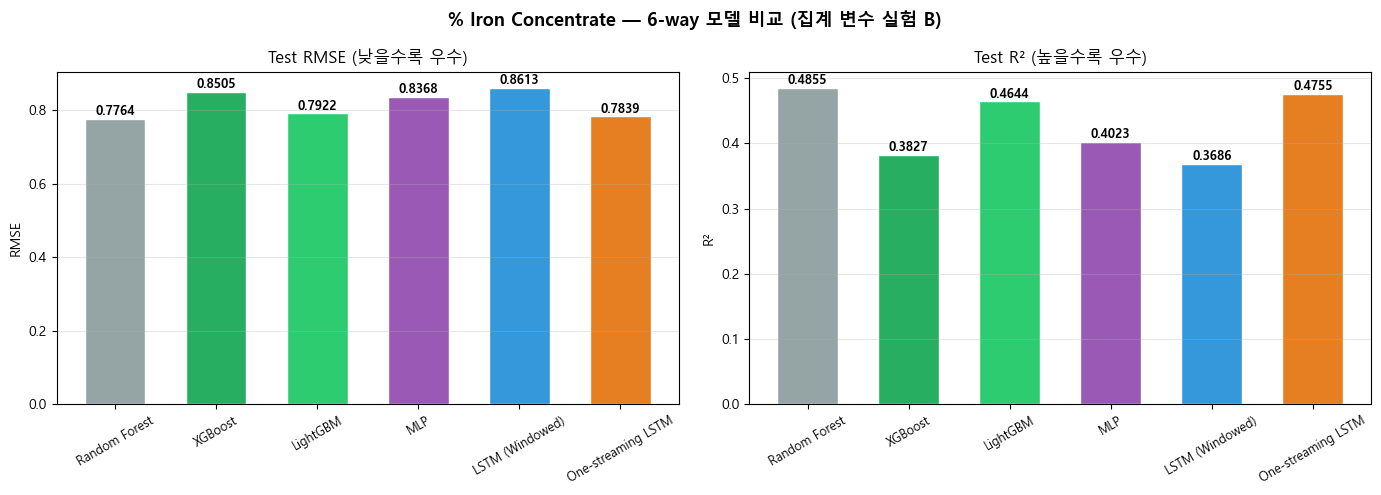

저장 완료: fe_model_comparison.png


In [22]:
# ── 6-way 비교 (XGBoost res_B 구조 통일) ────────────────────────────────
res_xgb_B = {'cv_rmse': res_B['cv_rmse'], 'test_rmse': res_B['test_rmse'],
             'test_r2': res_B['test_r2'], 'pred': res_B['pred']}

all_models = {
    'Random Forest':        (res_rf_B,     '10-fold CV'),
    'XGBoost':              (res_xgb_B,    '10-fold CV'),
    'LightGBM':             (res_lgbm_B,   '10-fold CV'),
    'MLP':                  (res_mlp_B,    'EarlyStopping'),
    'LSTM (Windowed)':      (res_lstm_B,   'EarlyStopping'),
    'One-streaming LSTM':   (res_stream_B, 'EarlyStopping'),
}

SEP = '=' * 76
print(f'\n{SEP}')
print('  6-way 모델 비교 — % Iron Concentrate (집계 변수, 실험 B)')
print(SEP)
print(f'  {"모델":<24s}  {"CV RMSE":>10s}  {"Test RMSE":>10s}  {"Test R²":>8s}')
print(f'  {"-"*70}')
for name, (res, cv_m) in all_models.items():
    cv_str = f'{res["cv_rmse"]:.4f}' if res.get('cv_rmse') else '       N/A'
    print(f'  {name:<24s}  {cv_str:>10s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>8.4f}')
print(SEP)

# 시각화
model_labels = list(all_models.keys())
rmses  = [v[0]['test_rmse'] for v in all_models.values()]
r2s    = [v[0]['test_r2']   for v in all_models.values()]
colors = ['#95a5a6', '#27ae60', '#2ecc71', '#9b59b6', '#3498db', '#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title, ylabel in [
    (axes[0], rmses, 'Test RMSE (낮을수록 우수)', 'RMSE'),
    (axes[1], r2s,   'Test R² (높을수록 우수)',   'R²'),
]:
    bars = ax.bar(model_labels, vals, color=colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(max(vals)-min(vals))*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelrotation=30, labelsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('% Iron Concentrate — 6-way 모델 비교 (집계 변수 실험 B)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fe_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: fe_model_comparison.png')


In [23]:
!pip install optuna -q



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# ── Optuna 튜닝 — 상위 3개 트리 모델 ────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 100

def cv_rmse_opt(model, X_tr, y_tr):
    fold_size = len(X_tr) // K
    rmses = []
    for k in range(K):
        v0 = k * fold_size
        v1 = (k+1)*fold_size if k < K-1 else len(X_tr)
        vi = list(range(v0, v1))
        ti = list(range(0, v0)) + list(range(v1, len(X_tr)))
        model.fit(X_tr.iloc[ti], y_tr.iloc[ti])
        rmses.append(np.sqrt(mean_squared_error(y_tr.iloc[vi], model.predict(X_tr.iloc[vi]))))
    return float(np.mean(rmses))

def lgbm_obj(trial):
    return cv_rmse_opt(lgb.LGBMRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 300),
        max_depth         = trial.suggest_int('max_depth', 3, 15),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, n_jobs=-1, verbose=-1,
    ), X_B_train, y_train)

def xgb_obj(trial):
    return cv_rmse_opt(xgb.XGBRegressor(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, verbosity=0,
    ), X_B_train, y_train)

def rf_obj(trial):
    return cv_rmse_opt(RandomForestRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        max_depth         = trial.suggest_int('max_depth', 3, 30),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=42, n_jobs=-1,
    ), X_B_train, y_train)

print('Optuna 튜닝 시작 (모델당 100 trials)...')
study_lgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
print('\n[1/3] LightGBM...')
study_lgbm.optimize(lgbm_obj, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_lgbm.best_value:.4f}')

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
print('\n[2/3] XGBoost...')
study_xgb.optimize(xgb_obj, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_xgb.best_value:.4f}')

study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
print('\n[3/3] Random Forest...')
study_rf.optimize(rf_obj, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_rf.best_value:.4f}')
print('\n튜닝 완료!')


Optuna 튜닝 시작 (모델당 100 trials)...

[1/3] LightGBM...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.7272

[2/3] XGBoost...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.7254

[3/3] Random Forest...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.7304

튜닝 완료!



  Optuna 튜닝 전후 비교 — % Iron Concentrate
  모델                          Best CV RMSE   Test RMSE   Test R²
  ------------------------------------------------------------------
  LightGBM  (default)               0.7272      0.7922    0.4644
  LightGBM  (tuned)                      -      0.7234    0.5533
  XGBoost   (default)               0.7254      0.8505    0.3827
  XGBoost   (tuned)                      -      0.7240    0.5526
  RF        (default)               0.7304      0.7764    0.4855
  RF        (tuned)                      -      0.7245    0.5520

--------------------------------------------------------------
   split      LightGBM       XGBoost            RF
--------------------------------------------------------------
  60%      0.7285          0.7313        ★0.7261
  65%      0.7231        ★0.7231          0.7243
  70%    ★0.7234          0.7240          0.7245
  75%    ★0.7383          0.7407          0.7393
  80%      0.7455        ★0.7404          0.7493
-------------

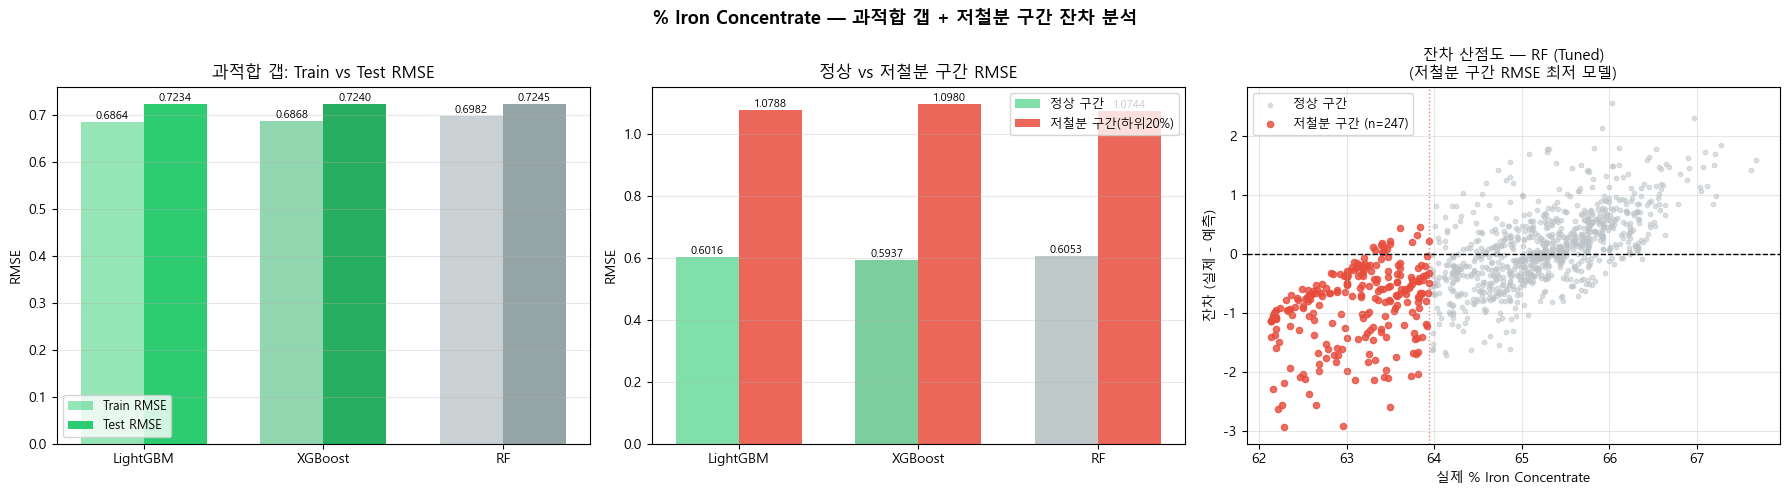

저장 완료: fe_residual_analysis.png


In [26]:
from sklearn.base import clone
import pandas as pd

# ── 최적 파라미터로 재학습 ────────────────────────────────────────────────
def eval_model(model, X_tr, X_te):
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)
    return {'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}

tuned_lgbm = lgb.LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
tuned_xgb  = xgb.XGBRegressor(**study_xgb.best_params,   random_state=42, verbosity=0)
tuned_rf   = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)

res_tuned_lgbm = eval_model(tuned_lgbm, X_B_train, X_B_test)
res_tuned_xgb  = eval_model(tuned_xgb,  X_B_train, X_B_test)
res_tuned_rf   = eval_model(tuned_rf,   X_B_train, X_B_test)

SEP = '=' * 70
print(f'\n{SEP}')
print('  Optuna 튜닝 전후 비교 — % Iron Concentrate')
print(SEP)
print(f'  {"모델":<26s}  {"Best CV RMSE":>12s}  {"Test RMSE":>10s}  {"Test R²":>8s}')
print(f'  {"-"*66}')
for name, res, cv_val in [
    ('LightGBM  (default)', res_lgbm_B,    study_lgbm.best_value),
    ('LightGBM  (tuned)',   res_tuned_lgbm, None),
    ('XGBoost   (default)', res_xgb_B,      study_xgb.best_value),
    ('XGBoost   (tuned)',   res_tuned_xgb,  None),
    ('RF        (default)', res_rf_B,        study_rf.best_value),
    ('RF        (tuned)',   res_tuned_rf,    None),
]:
    cv_str = f'{cv_val:.4f}' if cv_val else '          -'
    print(f'  {name:<26s}  {cv_str:>12s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>8.4f}')
print(SEP)

# ── 안정성 검증 (5회 split) ───────────────────────────────────────────────
X_full = pd.concat([X_B_train, X_B_test])
y_full = pd.concat([y_train, y_test])
n_full = len(X_full)
split_ratios  = [0.60, 0.65, 0.70, 0.75, 0.80]
model_names   = ['LightGBM (Tuned)', 'XGBoost (Tuned)', 'RF (Tuned)']
base_models   = [tuned_lgbm, tuned_xgb, tuned_rf]
stability_rec = {name: [] for name in model_names}

DSEP = '-' * 62
print(f'\n{DSEP}')
print(f'  {"split":>6s}  {"LightGBM":>12s}  {"XGBoost":>12s}  {"RF":>12s}')
print(DSEP)
for ratio in split_ratios:
    sp = int(n_full * ratio)
    X_tr, X_te = X_full.iloc[:sp], X_full.iloc[sp:]
    y_tr, y_te = y_full.iloc[:sp], y_full.iloc[sp:]
    row = []
    for name, base in zip(model_names, base_models):
        m = clone(base)
        m.fit(X_tr, y_tr)
        rmse = float(np.sqrt(mean_squared_error(y_te, m.predict(X_te))))
        stability_rec[name].append(rmse)
        row.append(rmse)
    best_idx = int(np.argmin(row))
    markers  = ['★' if i == best_idx else '  ' for i in range(3)]
    print(f'  {ratio:.0%}    {markers[0]}{row[0]:.4f}        {markers[1]}{row[1]:.4f}        {markers[2]}{row[2]:.4f}')
print(DSEP)
means = {n: float(np.mean(v)) for n, v in stability_rec.items()}
stds  = {n: float(np.std(v))  for n, v in stability_rec.items()}
print(f'  {"평균":>6s}', end='')
for n in model_names: print(f'  {means[n]:>12.4f}', end='')
print()
print(f'  {"표준편차":>6s}', end='')
for n in model_names: print(f'  {stds[n]:>12.4f}', end='')
print(f'\n{DSEP}')
final_winner = min(means, key=means.get)
print(f'\n  ★ 5회 평균 기준 최종 우승: {final_winner}')
print(f'     평균 RMSE = {means[final_winner]:.4f} ± {stds[final_winner]:.4f}')

# ── 과적합 갭 + 저농도 구간 잔차 분석 (Fe: 저철분 = 공정 이상) ───────────
train_rmses, test_rmses_t, gaps = [], [], []
test_preds = [res_tuned_lgbm['pred'], res_tuned_xgb['pred'], res_tuned_rf['pred']]
for base, pred_te in zip(base_models, test_preds):
    m = clone(base)
    m.fit(X_B_train, y_train)
    tr_rmse = float(np.sqrt(mean_squared_error(y_train, m.predict(X_B_train))))
    te_rmse = float(np.sqrt(mean_squared_error(y_test,  pred_te)))
    train_rmses.append(tr_rmse)
    test_rmses_t.append(te_rmse)
    gaps.append(te_rmse - tr_rmse)

# Fe: 저철분 구간 = 하위 20% (공정 이상)
y_te_arr  = y_test.values
threshold = np.percentile(y_te_arr, 20)
low_mask  = y_te_arr <= threshold
norm_mask = ~low_mask
low_rmses, norm_rmses = [], []
for pred_te in test_preds:
    resid = y_te_arr - pred_te
    low_rmses.append(float(np.sqrt(np.mean(resid[low_mask]**2))))
    norm_rmses.append(float(np.sqrt(np.mean(resid[norm_mask]**2))))

print(f'\n{SEP}')
print(f'  {"모델":<22s}  {"Train":>8s}  {"Test":>8s}  {"Gap":>8s}  {"정상구간":>8s}  {"저철분구간(하위20%)":>18s}')
print(f'  {"-"*66}')
for name, tr, te, gap, nr, lr in zip(model_names, train_rmses, test_rmses_t, gaps, norm_rmses, low_rmses):
    print(f'  {name:<22s}  {tr:>8.4f}  {te:>8.4f}  {gap:>+8.4f}  {nr:>8.4f}  {lr:>18.4f}')
print(SEP)
print(f'  ※ 저철분 구간: y_test 하위 20% (threshold = {threshold:.4f})')
print(f'  ※ 저철분 = Fe 농도 낮음 = 공정 이상 → 제어 중요 구간')

# ── 시각화 ───────────────────────────────────────────────────────────────
colors_map = {'LightGBM (Tuned)': '#2ecc71', 'XGBoost (Tuned)': '#27ae60', 'RF (Tuned)': '#95a5a6'}
colors     = [colors_map[n] for n in model_names]
x, w       = np.arange(3), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 과적합 갭
b1 = axes[0].bar(x - w/2, train_rmses,   w, label='Train RMSE', color=colors, alpha=0.5)
b2 = axes[0].bar(x + w/2, test_rmses_t,  w, label='Test RMSE',  color=colors, alpha=1.0)
for bar, val in zip(list(b1)+list(b2), train_rmses+test_rmses_t):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(['LightGBM', 'XGBoost', 'RF'])
axes[0].set_title('과적합 갭: Train vs Test RMSE', fontsize=12)
axes[0].set_ylabel('RMSE'); axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# (2) 정상 vs 저철분 구간
b3 = axes[1].bar(x - w/2, norm_rmses, w, label='정상 구간',        color=colors, alpha=0.6)
b4 = axes[1].bar(x + w/2, low_rmses,  w, label='저철분 구간(하위20%)', color='#e74c3c', alpha=0.85)
for bar, val in zip(list(b3)+list(b4), norm_rmses+low_rmses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(['LightGBM', 'XGBoost', 'RF'])
axes[1].set_title('정상 vs 저철분 구간 RMSE', fontsize=12)
axes[1].set_ylabel('RMSE'); axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

# (3) 잔차 산점도
best_low_idx  = int(np.argmin(low_rmses))
best_pred     = test_preds[best_low_idx]
resid         = y_te_arr - best_pred
axes[2].scatter(y_te_arr[norm_mask], resid[norm_mask], color='#bdc3c7', s=10, alpha=0.5, label='정상 구간')
axes[2].scatter(y_te_arr[low_mask],  resid[low_mask],  color='#e74c3c', s=20, alpha=0.8,
                label=f'저철분 구간 (n={low_mask.sum()})')
axes[2].axhline(0, color='black', lw=1, linestyle='--')
axes[2].axvline(threshold, color='#e74c3c', lw=1, linestyle=':', alpha=0.7)
axes[2].set_title(f'잔차 산점도 — {model_names[best_low_idx]}\n(저철분 구간 RMSE 최저 모델)', fontsize=11)
axes[2].set_xlabel('실제 % Iron Concentrate')
axes[2].set_ylabel('잔차 (실제 - 예측)')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('% Iron Concentrate — 과적합 갭 + 저철분 구간 잔차 분석',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fe_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: fe_residual_analysis.png')


In [27]:

# ── 튜닝 모델 저장 (Optuna 재실행 방지) ─────────────────────────────────────
# 처음 한 번만 실행. 이후엔 아래 로드 셀만 실행하면 됨.
import joblib
joblib.dump(tuned_lgbm, 'fe_tuned_lgbm.pkl')
joblib.dump(tuned_xgb,  'fe_tuned_xgb.pkl')
joblib.dump(tuned_rf,   'fe_tuned_rf.pkl')
print('모델 저장 완료')

# ── 다음 번 실행 시 아래 코드로 불러오기 (Optuna 셀 건너뛰고 이것만 실행) ──
# import joblib
# tuned_lgbm = joblib.load('fe_tuned_lgbm.pkl')
# tuned_xgb  = joblib.load('fe_tuned_xgb.pkl')
# tuned_rf   = joblib.load('fe_tuned_rf.pkl')
# print('모델 로드 완료')

모델 저장 완료


In [28]:
# ── One-streaming LSTM 재현성 확인 (seed 3개) ─────────────────────────────
import numpy as np
import random
import os

SEEDS = [42, 123, 2024]
seed_results = []

for seed in SEEDS:
    # 모든 랜덤 시드 고정
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 스트리밍 LSTM 모델 재정의 (해당 seed 적용)
    def build_streaming_lstm_seed(n_features, seed):
        tf.random.set_seed(seed)
        inp = keras.Input(batch_shape=(1, 1, n_features))
        x   = layers.LSTM(64, stateful=True, return_sequences=True)(inp)
        x   = layers.Dropout(0.2)(x)
        x   = layers.LSTM(32, stateful=True)(x)
        x   = layers.Dropout(0.2)(x)
        out = layers.Dense(1)(x)
        model = keras.Model(inp, out)
        model.compile(optimizer='adam', loss='mse')
        return model

    X_tr_s, X_te_s = scale(X_B_train, X_B_test)
    y_sc = StandardScaler()
    y_tr_s = y_sc.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    n = X_B_train.shape[1]

    n_val    = int(len(X_tr_s) * 0.1)
    X_fit    = X_tr_s[:-n_val].reshape(-1, 1, n)
    y_fit    = y_tr_s[:-n_val]
    X_val    = X_tr_s[-n_val:].reshape(-1, 1, n)
    y_val    = y_tr_s[-n_val:]
    X_tr_st  = X_tr_s.reshape(-1, 1, n)
    X_te_st  = X_te_s.reshape(-1, 1, n)

    model = build_streaming_lstm_seed(n, seed)
    best_val, patience_cnt, best_w, stopped = np.inf, 0, None, 0
    for epoch in range(100):
        reset_states(model)
        model.fit(X_fit, y_fit, batch_size=1, shuffle=False, verbose=0)
        val_pred_s = model.predict(X_val, batch_size=1, verbose=0).flatten()
        val_mse    = float(np.mean((y_val - val_pred_s)**2))
        if val_mse < best_val:
            best_val, best_w, patience_cnt, stopped = val_mse, model.get_weights(), 0, epoch+1
        else:
            patience_cnt += 1
        if patience_cnt >= 10: break
    model.set_weights(best_w)
    reset_states(model)
    _ = model.predict(X_tr_st, batch_size=1, verbose=0)
    pred_s    = model.predict(X_te_st, batch_size=1, verbose=0).flatten()
    pred      = y_sc.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = r2_score(y_test, pred)

    seed_results.append({'seed': seed, 'rmse': test_rmse, 'r2': test_r2, 'epoch': stopped})
    print(f"[seed={seed:>4d}]  epoch: {stopped:>3d} | RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}")

rmses = [r['rmse'] for r in seed_results]
r2s   = [r['r2']   for r in seed_results]
print(f"평균  RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
print(f"평균  R²  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
print(f"[참고] Tuned RF  RMSE: 0.7245 | R²: 0.5520")
print(f"[참고] Tuned LGB RMSE: 0.7234 | R²: 0.5533")


[seed=  42]  epoch:   4 | RMSE: 0.7918 | R²: 0.4649
[seed= 123]  epoch:   3 | RMSE: 0.8100 | R²: 0.4400
[seed=2024]  epoch:   3 | RMSE: 0.8325 | R²: 0.4085
평균  RMSE: 0.8114 ± 0.0166
평균  R²  : 0.4378 ± 0.0231
[참고] Tuned RF  RMSE: 0.7245 | R²: 0.5520
[참고] Tuned LGB RMSE: 0.7234 | R²: 0.5533
